# 05 Model Tuning on Dev-Noisy (Baseline MLP)

This notebook performs **model tuning** using only dev-noisy data.

Tuning targets in this notebook:
- model checkpoint selection (compare multiple trained checkpoints)
- decision threshold selection (choose threshold that maximizes dev F1)

No test-noisy data is used in this notebook.

### Step 1: Import libraries
This step imports plotting, metrics, tensor, and utility libraries used throughout validation and checkpoint comparison.

In [1]:
import json
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    )

### Step 2: Resolve project paths and runtime config
This step finds the repository root, adds Step 05 modules to Python path, and sets shared configuration such as data paths, device, checkpoint filters, and threshold grid.

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'src').exists() and (candidate / 'data' / 'generated').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from current working directory.')

ROOT = find_project_root(Path.cwd())
SRC_05 = ROOT / 'src' / '05_baseline_training'
if str(SRC_05) not in sys.path:
    sys.path.insert(0, str(SRC_05))

from baseline_mlp import BaselineMLP
from offline_dataset import build_dataloader

DATA_ROOT = ROOT / 'data' / 'generated'
ARTIFACTS_DIR = ROOT / 'artifacts'
CHECKPOINT_DIR = ARTIFACTS_DIR / 'checkpoints'

BATCH_SIZE = 2048
NUM_WORKERS = 4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CHECKPOINT_SUFFIXES = {'.pt', '.pth', '.ckpt'}
CHECKPOINT_NAME_CONTAINS = 'baseline_mlp'
THRESHOLDS = np.linspace(0.05, 0.95, 19)
TOP_K_PLOTS = 10

print('Project root        :', ROOT)
print('Step 05 src         :', SRC_05)
print('Data root           :', DATA_ROOT)
print('Checkpoint directory:', CHECKPOINT_DIR)
print('Device              :', DEVICE)

Project root        : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
Step 05 src         : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/05_baseline_training
Data root           : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated
Checkpoint directory: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/checkpoints
Device              : cuda


### Step 3: Define checkpoint/model helper functions
This step defines reusable helpers for loading checkpoint formats, inferring model shape, constructing the model safely, and collecting logits/labels from the dataloader.

In [3]:
def _extract_state_dict(obj):
    if isinstance(obj, dict):
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            return obj['state_dict']
        if 'model_state_dict' in obj and isinstance(obj['model_state_dict'], dict):
            return obj['model_state_dict']
    return obj


def _infer_mlp_shape_from_state(state_dict):
    linear_layers = []
    for k, v in state_dict.items():
        if not (k.startswith('backbone.') and k.endswith('.weight')):
            continue
        if not hasattr(v, 'shape') or len(v.shape) != 2:
            continue
        parts = k.split('.')
        if len(parts) < 3 or not parts[1].isdigit():
            continue
        idx = int(parts[1])
        out_dim, in_dim = int(v.shape[0]), int(v.shape[1])
        linear_layers.append((idx, in_dim, out_dim))

    if not linear_layers:
        raise RuntimeError('Could not infer backbone layers from checkpoint state_dict.')

    linear_layers.sort(key=lambda t: t[0])
    input_dim = linear_layers[0][1]
    hidden_dims = tuple(layer[2] for layer in linear_layers)
    dropout = 0.1 if len(linear_layers) >= 2 and (linear_layers[1][0] - linear_layers[0][0] == 3) else 0.0
    return input_dim, hidden_dims, dropout


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> BaselineMLP:
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = _extract_state_dict(raw)
    if not isinstance(state, dict):
        raise RuntimeError('Checkpoint does not contain a valid state_dict.')

    input_dim, hidden_dims, dropout = _infer_mlp_shape_from_state(state)
    model = BaselineMLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout)
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    return model


def collect_logits_labels(loader, model, device):
    logits_all = []
    labels_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x).detach().cpu().numpy()
            labels = y.detach().cpu().numpy().astype(np.int64)
            logits_all.append(logits)
            labels_all.append(labels)

    if not logits_all:
        raise RuntimeError('No samples collected from loader.')

    return np.concatenate(logits_all), np.concatenate(labels_all)

### Step 4: Build dev dataloader and discover checkpoints
This step builds the dev-noisy dataloader and scans artifacts/checkpoints for candidate model files to evaluate.

In [4]:
loader = build_dataloader(
    generated_dir=DATA_ROOT / 'dev',
    split='dev',
    manifest_type="noisy",
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

ckpt_candidates = sorted(
    [
        p for p in CHECKPOINT_DIR.rglob('*')
        if p.is_file() and p.suffix in CHECKPOINT_SUFFIXES
    ]
)
if CHECKPOINT_NAME_CONTAINS:
    key = CHECKPOINT_NAME_CONTAINS.lower()
    ckpt_candidates = [p for p in ckpt_candidates if key in p.name.lower()]

print('Dataset size          :', len(loader.dataset))
print('Checkpoint candidates :', len(ckpt_candidates))
for p in ckpt_candidates[:20]:
    print(' -', p.name)

if not ckpt_candidates:
    raise FileNotFoundError(f'No checkpoint files found under: {CHECKPOINT_DIR}')

Dataset size          : 1088453
Checkpoint candidates : 12
 - baseline_mlp_lr0.0003_wd0_dr0.0_seed42.pt
 - baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt
 - baseline_mlp_lr0.0003_wd1e-4_dr0.0_seed42.pt
 - baseline_mlp_lr0.0003_wd1e-4_dr0.1_seed42.pt
 - baseline_mlp_lr0.0003_wd1e-5_dr0.0_seed42.pt
 - baseline_mlp_lr0.0003_wd1e-5_dr0.1_seed42.pt
 - baseline_mlp_lr0.001_wd0_dr0.0_seed42.pt
 - baseline_mlp_lr0.001_wd0_dr0.1_seed42.pt
 - baseline_mlp_lr0.001_wd1e-4_dr0.0_seed42.pt
 - baseline_mlp_lr0.001_wd1e-4_dr0.1_seed42.pt
 - baseline_mlp_lr0.001_wd1e-5_dr0.0_seed42.pt
 - baseline_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt


### Step 5: Evaluate all checkpoints and tune threshold per checkpoint
This step runs inference for each checkpoint on dev-noisy, performs threshold sweep, records best metrics for each model, and selects the top checkpoint by best dev F1.

In [5]:
def metrics_at_threshold(probs, labels, thr=0.5):
    pred = (probs >= thr).astype(np.int64)
    y = labels.astype(np.int64)

    tp = int(np.sum((pred == 1) & (y == 1)))
    tn = int(np.sum((pred == 0) & (y == 0)))
    fp = int(np.sum((pred == 1) & (y == 0)))
    fn = int(np.sum((pred == 0) & (y == 1)))

    acc = (tp + tn) / max(1, tp + tn + fp + fn)
    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = (2.0 * prec * rec) / max(1e-12, (prec + rec))

    # FAR: false alarms among actual non-speech frames
    far = fp / max(1, fp + tn)
    # Miss rate: missed speech among actual speech frames
    miss_rate = fn / max(1, fn + tp)

    return {
        'threshold': float(thr),
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'far': float(far),
        'miss_rate': float(miss_rate),
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


results = []
failures = []

best_model = None
all_logits = None
all_labels = None
probs = None

for i, ckpt in enumerate(ckpt_candidates, start=1):
    try:
        model = load_model_from_checkpoint(ckpt, DEVICE)
        logits_i, labels_i = collect_logits_labels(loader, model, DEVICE)
        probs_i = 1.0 / (1.0 + np.exp(-logits_i))

        sweep_i = [metrics_at_threshold(probs_i, labels_i, thr=float(t)) for t in THRESHOLDS]
        best_idx = int(np.argmax([m['f1'] for m in sweep_i]))
        best_point = sweep_i[best_idx]

        result = {
            'checkpoint': str(ckpt),
            'checkpoint_name': ckpt.name,
            'best_threshold': best_point['threshold'],
            'accuracy': best_point['accuracy'],
            'precision': best_point['precision'],
            'recall': best_point['recall'],
            'f1': best_point['f1'],
            'far': best_point['far'],
            'miss_rate': best_point['miss_rate'],
            'tp': best_point['tp'],
            'tn': best_point['tn'],
            'fp': best_point['fp'],
            'fn': best_point['fn'],
            'sweep': sweep_i,
        }
        results.append(result)

        if best_model is None or result['f1'] > best_model['f1']:
            best_model = result
            all_logits = logits_i
            all_labels = labels_i
            probs = probs_i

        print(
            f"[{i:02d}/{len(ckpt_candidates)}] OK  {ckpt.name} | "
            f"F1={result['f1']:.6f}, P={result['precision']:.4f}, R={result['recall']:.4f}, "
            f"FAR={result['far']:.4f}, Miss={result['miss_rate']:.4f} @thr={result['best_threshold']:.2f}"
        )
    except Exception as e:
        failures.append((str(ckpt), repr(e)))
        print(f"[{i:02d}/{len(ckpt_candidates)}] FAIL {ckpt.name} | {e}")

if not results:
    raise RuntimeError('No checkpoint evaluated successfully.')

ranked = sorted(results, key=lambda r: r['f1'], reverse=True)
best_model = ranked[0]
best_threshold = float(best_model['best_threshold'])
preds = (probs >= best_threshold).astype(int)

print('\nBest checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print(
    "Best metrics   : "
    f"F1={best_model['f1']:.6f}, "
    f"Precision={best_model['precision']:.6f}, "
    f"Recall={best_model['recall']:.6f}, "
    f"FAR={best_model['far']:.6f}, "
    f"MissRate={best_model['miss_rate']:.6f}"
)
print('Failures       :', len(failures))

[01/12] OK  baseline_mlp_lr0.0003_wd0_dr0.0_seed42.pt | F1=0.845518, P=0.7410, R=0.9844, FAR=0.7728, Miss=0.0156 @thr=0.10
[02/12] OK  baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt | F1=0.845633, P=0.7412, R=0.9844, FAR=0.7719, Miss=0.0156 @thr=0.15
[03/12] OK  baseline_mlp_lr0.0003_wd1e-4_dr0.0_seed42.pt | F1=0.845431, P=0.7415, R=0.9832, FAR=0.7696, Miss=0.0168 @thr=0.10
[04/12] OK  baseline_mlp_lr0.0003_wd1e-4_dr0.1_seed42.pt | F1=0.845334, P=0.7408, R=0.9842, FAR=0.7733, Miss=0.0158 @thr=0.05
[05/12] OK  baseline_mlp_lr0.0003_wd1e-5_dr0.0_seed42.pt | F1=0.845571, P=0.7407, R=0.9851, FAR=0.7745, Miss=0.0149 @thr=0.10
[06/12] OK  baseline_mlp_lr0.0003_wd1e-5_dr0.1_seed42.pt | F1=0.845600, P=0.7412, R=0.9842, FAR=0.7714, Miss=0.0158 @thr=0.10
[07/12] OK  baseline_mlp_lr0.001_wd0_dr0.0_seed42.pt | F1=0.845505, P=0.7428, R=0.9812, FAR=0.7629, Miss=0.0188 @thr=0.30
[08/12] OK  baseline_mlp_lr0.001_wd0_dr0.1_seed42.pt | F1=0.845969, P=0.7420, R=0.9839, FAR=0.7683, Miss=0.0161 @thr=0.10
[09/12

**Output explanation**

The baseline model trained on clean data performs significantly worse when evaluated on noisy data, with the best F1 score dropping to around 0.846. While recall remains very high (above 0.98), precision decreases to around 0.74, resulting in a very high false alarm rate (around 0.77). This indicates that the model tends to incorrectly classify noise as speech, leading to many false positives. The optimal threshold is much lower (around 0.05), which reflects the model’s need to be more conservative in noisy conditions. Overall, the results highlight that a model trained only on clean data does not generalize well to noisy environments, demonstrating the importance of training with noisy data for robust performance.

### Step 6: Print checkpoint leaderboard
This step prints a ranked table of all successfully evaluated checkpoints, including each model's best threshold and metrics.

In [6]:
print('Top checkpoints by dev F1:')
print('-' * 132)
print(f"{'rank':>4s}  {'checkpoint':<55s}  {'thr':>5s}  {'f1':>9s}  {'acc':>9s}  {'prec':>9s}  {'rec':>9s}  {'far':>9s}  {'miss':>9s}")
print('-' * 132)

for idx, r in enumerate(ranked, start=1):
    print(
        f"{idx:>4d}  {r['checkpoint_name']:<55.55s}  {r['best_threshold']:>5.2f}  "
        f"{r['f1']:>9.6f}  {r['accuracy']:>9.6f}  {r['precision']:>9.6f}  {r['recall']:>9.6f}  "
        f"{r['far']:>9.6f}  {r['miss_rate']:>9.6f}"
    )

if failures:
    print('\nFailed checkpoints:')
    for ckpt, err in failures:
        print(' -', Path(ckpt).name, '|', err)

Top checkpoints by dev F1:
------------------------------------------------------------------------------------------------------------------------------------
rank  checkpoint                                                 thr         f1        acc       prec        rec        far       miss
------------------------------------------------------------------------------------------------------------------------------------
   1  baseline_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt               0.05   0.846023   0.751879   0.741291   0.985218   0.772070   0.014782
   2  baseline_mlp_lr0.001_wd0_dr0.1_seed42.pt                  0.10   0.845969   0.752116   0.741975   0.983866   0.768265   0.016134
   3  baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt                 0.15   0.845633   0.751347   0.741166   0.984380   0.771915   0.015620
   4  baseline_mlp_lr0.0003_wd1e-5_dr0.1_seed42.pt              0.10   0.845600   0.751340   0.741241   0.984160   0.771444   0.015840
   5  baseline_mlp_lr0.0003_wd1e

**Output explanation**

The results show that all baseline models perform very similarly on noisy data, with F1 scores tightly clustered around 0.845–0.846, indicating low sensitivity to hyperparameter changes. The best model achieves an F1 score of 0.846 with a learning rate of 0.001, weight decay of 1e-5, and dropout of 0.1. Across all models, recall remains very high (around 0.98), while precision is relatively low (around 0.74), resulting in consistently high false alarm rates (around 0.76–0.77). This suggests that the model tends to over-predict speech in noisy conditions. The optimal thresholds are generally low (0.05–0.15), reflecting the need to adjust decision boundaries under noise. Overall, the results confirm that models trained on clean data struggle to generalize to noisy environments, regardless of hyperparameter tuning.

### Step 7: Compare metrics across top checkpoints
This step visualizes accuracy, precision, recall, and F1 across top models so performance differences are easy to compare side by side.

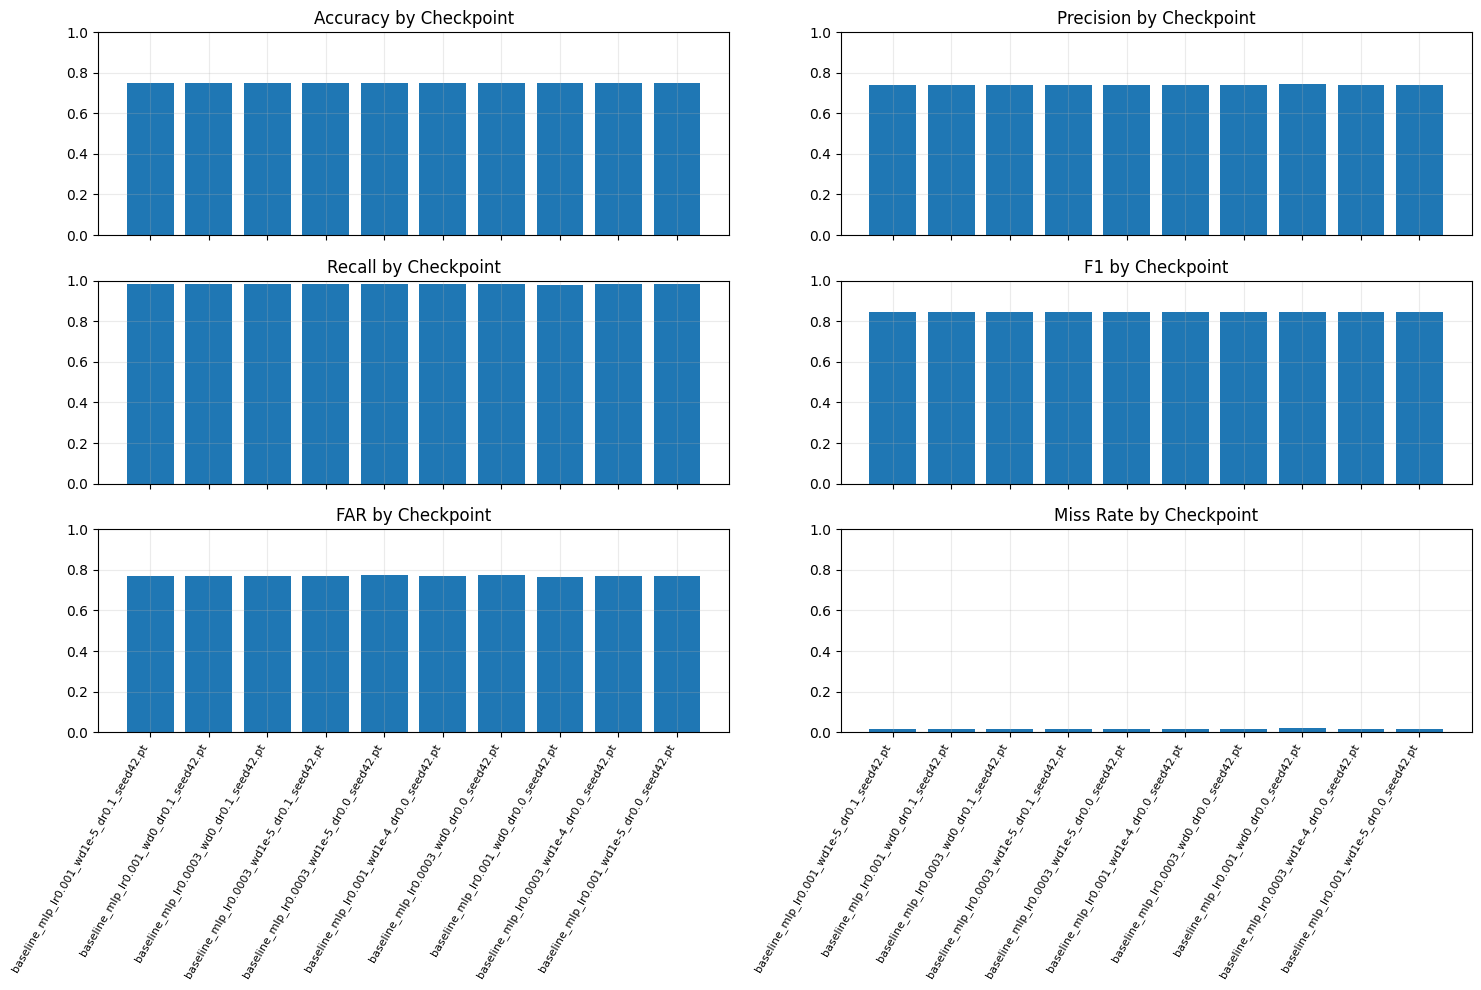

Best checkpoint: baseline_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt
Best threshold : 0.05
Best metrics   : acc=0.751879,  prec=0.741291,  rec=0.985218,  f1=0.846023,  far=0.772070,  miss=0.014782


In [7]:
top = ranked[: min(TOP_K_PLOTS, len(ranked))]
names = [r['checkpoint_name'] for r in top]
x = np.arange(len(top))

acc_vals = [r['accuracy'] for r in top]
prec_vals = [r['precision'] for r in top]
rec_vals = [r['recall'] for r in top]
f1_vals = [r['f1'] for r in top]
far_vals = [r['far'] for r in top]
miss_vals = [r['miss_rate'] for r in top]

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
axes = axes.ravel()

axes[0].bar(x, acc_vals)
axes[0].set_title('Accuracy by Checkpoint')
axes[0].set_ylim(0, 1)

axes[1].bar(x, prec_vals)
axes[1].set_title('Precision by Checkpoint')
axes[1].set_ylim(0, 1)

axes[2].bar(x, rec_vals)
axes[2].set_title('Recall by Checkpoint')
axes[2].set_ylim(0, 1)

axes[3].bar(x, f1_vals)
axes[3].set_title('F1 by Checkpoint')
axes[3].set_ylim(0, 1)

axes[4].bar(x, far_vals)
axes[4].set_title('FAR by Checkpoint')
axes[4].set_ylim(0, 1)

axes[5].bar(x, miss_vals)
axes[5].set_title('Miss Rate by Checkpoint')
axes[5].set_ylim(0, 1)

for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('Best checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print('Best metrics   :',
      f"acc={best_model['accuracy']:.6f}, ",
      f"prec={best_model['precision']:.6f}, ",
      f"rec={best_model['recall']:.6f}, ",
      f"f1={best_model['f1']:.6f}, ",
      f"far={best_model['far']:.6f}, ",
      f"miss={best_model['miss_rate']:.6f}")

**Output explanation**

The plots show that all baseline models evaluated on noisy data have very similar performance across all metrics. Accuracy stays around 0.75, while precision is relatively low (around 0.74) compared to recall, which remains very high (close to 1.0). As a result, the F1 score is consistently around 0.845 across all checkpoints. The FAR plot shows very high values (around 0.76–0.77), indicating a large number of false positives, while the miss rate remains very low, meaning the model rarely misses actual speech. This confirms that the model is biased toward predicting speech in noisy conditions. Overall, the plots highlight that hyperparameter changes have minimal impact, and the main limitation is poor generalization from clean training to noisy data.

### Step 8: Visualize confusion matrix for best checkpoint
This step plots the confusion matrix of the selected best model using its tuned decision threshold.

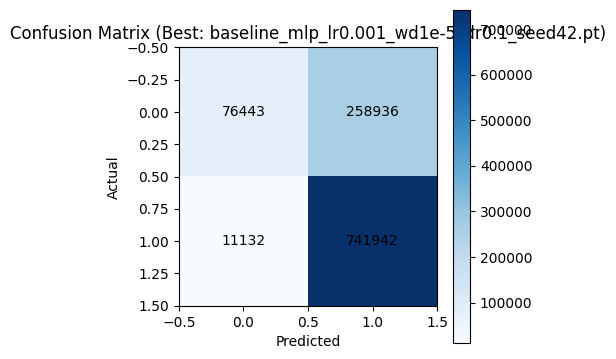

In [8]:
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(4.5, 4.0))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix (Best: {best_model['checkpoint_name']})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

**Output explanation**

The confusion matrix on the dev-noisy dataset shows that the model correctly identifies a large number of speech frames (741,942 true positives) and maintains high recall. However, it also produces a substantial number of false positives (258,936), which explains the lower precision observed in earlier metrics. The number of false negatives (11,132) is relatively small, indicating that the model rarely misses actual speech. True negatives (76,443) are also much lower compared to false positives, suggesting that the model tends to over-predict speech in noisy conditions. Overall, this confirms that under noise, the model prioritizes capturing speech (high recall) at the cost of misclassifying more non-speech as speech (lower precision).

### Step 9: Plot ROC curve for best checkpoint
This step computes and visualizes the ROC curve and AUC for the selected best model on dev-noisy.

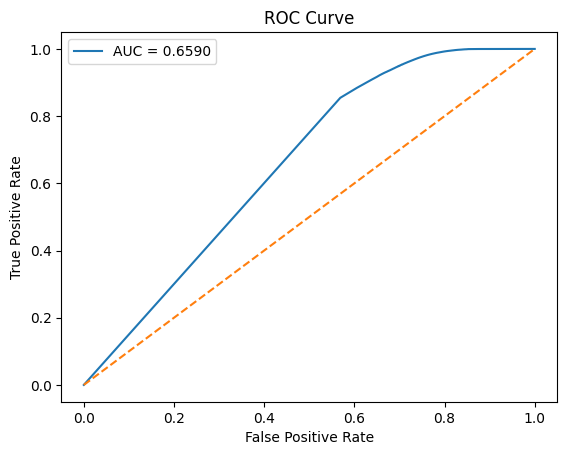

In [9]:
fpr, tpr, _ = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Output explanation**

The ROC curve on the dev-noisy dataset shows a significant drop in performance compared to the clean setting, with an AUC of approximately 0.659. The curve lies much closer to the diagonal baseline, indicating that the model’s ability to distinguish between speech and non-speech is substantially reduced in noisy conditions. This suggests that noise makes the feature representations less separable, leading to higher overlap between classes. As a result, the model produces more false positives while still maintaining relatively high true positive rates. Overall, the ROC curve confirms that noise degrades the model’s discriminative power and makes classification more challenging.

### Step 10: Plot precision-recall curve for best checkpoint
This step visualizes the precision-recall trade-off, which is often informative for imbalanced frame-level classification tasks.

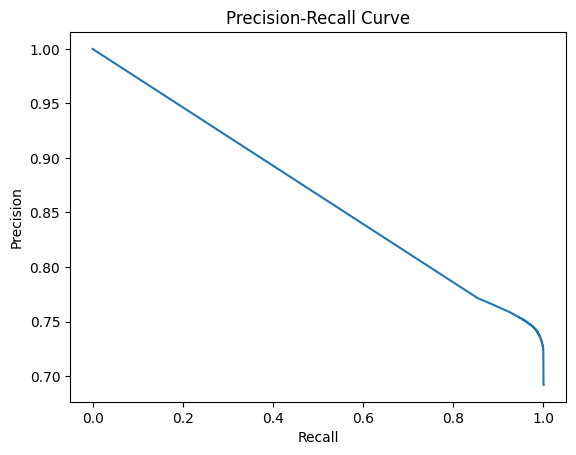

In [10]:
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, probs)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Output explanation**

The precision–recall curve on the dev-noisy dataset shows a clear trade-off between precision and recall. As recall increases, precision steadily decreases, indicating that capturing more speech frames comes at the cost of introducing more false positives. Unlike the clean setting where precision remains near perfect, the curve here drops significantly from 1.0 to around 0.7, reflecting the difficulty of distinguishing speech from noise. The model achieves high recall close to 1.0, but precision is noticeably lower, confirming that it tends to over-predict speech in noisy conditions. Overall, the curve highlights the reduced reliability of the model under noise and emphasizes the importance of threshold tuning to balance precision and recall.

### Step 11: Re-check threshold sweep on best checkpoint
This step recomputes F1 across thresholds for the selected best checkpoint and verifies the chosen operating point.

In [11]:
thresholds = THRESHOLDS
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1_scores.append(f1_score(all_labels, preds_t))

best_idx = int(np.argmax(f1_scores))
best_threshold_from_curve = float(thresholds[best_idx])

print('Best checkpoint       :', best_model['checkpoint_name'])
print('Best threshold (saved):', best_threshold)
print('Best threshold (curve):', best_threshold_from_curve)
print('Best F1 (curve)       :', f1_scores[best_idx])

Best checkpoint       : baseline_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt
Best threshold (saved): 0.05
Best threshold (curve): 0.05
Best F1 (curve)       : 0.8460231522869497


**Output explanation**

The best-performing model on the dev-noisy dataset is the checkpoint trained with a learning rate of 0.001, weight decay of 1e-5, and dropout of 0.1. Both the saved threshold and the optimal threshold from the precision–recall curve are 0.05, showing consistent threshold selection. At this threshold, the model achieves an F1 score of approximately 0.8460. The much lower optimal threshold compared to the clean setting indicates that the model must predict speech more aggressively in noisy conditions to maintain high recall. Overall, this configuration provides the best balance between precision and recall under noise, despite the overall performance being lower than in clean data.

### Step 12: Visualize F1 versus threshold
This step plots the F1-threshold curve for the best checkpoint to make threshold behavior easy to inspect.

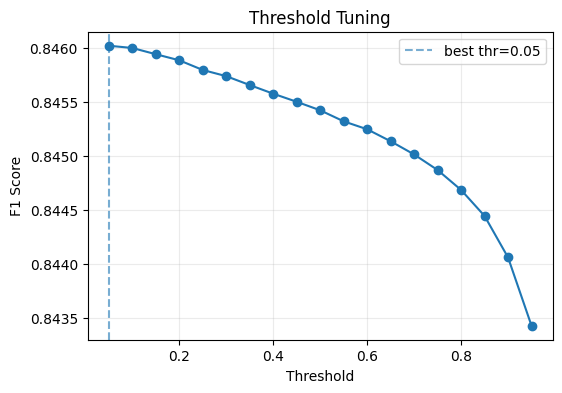

Best threshold from curve: 0.05
Best F1 from curve       : 0.846023


In [14]:
thresholds = THRESHOLDS
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(np.int64)
    f1_scores.append(f1_score(all_labels, preds_t))

best_idx = int(np.argmax(f1_scores))
best_thr_curve = float(thresholds[best_idx])
best_f1_curve = float(f1_scores[best_idx])

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_thr_curve, linestyle='--', alpha=0.6, label=f'best thr={best_thr_curve:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Best threshold from curve: {best_thr_curve:.2f}")
print(f"Best F1 from curve       : {best_f1_curve:.6f}")

**Output explanation**

The threshold tuning curve on the dev-noisy dataset shows that the F1 score is highest at a very low threshold around 0.05 and gradually decreases as the threshold increases. This indicates that the model performs best when it predicts speech more aggressively in noisy conditions. As the threshold becomes higher, the model becomes more conservative, leading to more missed speech frames and a drop in recall, which lowers the F1 score. Unlike the clean setting where the optimal threshold is higher, the noisy environment shifts the optimal point toward lower thresholds. Overall, the curve highlights that threshold selection is more sensitive under noise and plays a critical role in maintaining performance.

### Step 13: Export evaluation artifacts and tuned configuration
This step saves prediction arrays, the checkpoint leaderboard, and the final tuned config for reproducible downstream testing/reporting.

In [13]:
eval_dir = ARTIFACTS_DIR / 'eval_outputs_noisy_baseline_mlp'
eval_dir.mkdir(parents=True, exist_ok=True)

np.save(eval_dir / 'eval_logits.npy', all_logits)
np.save(eval_dir / 'eval_probs.npy', probs)
np.save(eval_dir / 'eval_labels.npy', all_labels)

with open(eval_dir / 'checkpoint_leaderboard.json', 'w', encoding='utf-8') as f:
    json.dump(
        [
            {
                'checkpoint': r['checkpoint'],
                'checkpoint_name': r['checkpoint_name'],
                'best_threshold': r['best_threshold'],
                'accuracy': r['accuracy'],
                'precision': r['precision'],
                'recall': r['recall'],
                'f1': r['f1'],
                'far': r['far'],
                'miss_rate': r['miss_rate'],
                'tp': r['tp'],
                'tn': r['tn'],
                'fp': r['fp'],
                'fn': r['fn'],
            }
            for r in ranked
        ],
        f,
        indent=2,
    )

noisy_config_path = ARTIFACTS_DIR / 'final_tuned_config_noisy_baseline_mlp.json'
with open(noisy_config_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'checkpoint': best_model['checkpoint'],
            'threshold': best_threshold,
            'dev_metrics': {
                'accuracy': best_model['accuracy'],
                'precision': best_model['precision'],
                'recall': best_model['recall'],
                'f1': best_model['f1'],
                'far': best_model['far'],
                'miss_rate': best_model['miss_rate'],
                'tp': best_model['tp'],
                'tn': best_model['tn'],
                'fp': best_model['fp'],
                'fn': best_model['fn'],
            },
        },
        f,
        indent=2,
    )

print('Saved evaluation arrays to:', eval_dir)
print('Saved leaderboard to     :', eval_dir / 'checkpoint_leaderboard.json')
print('Saved tuned config to    :', noisy_config_path)

Saved evaluation arrays to: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_noisy_baseline_mlp
Saved leaderboard to     : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_noisy_baseline_mlp/checkpoint_leaderboard.json
Saved tuned config to    : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/final_tuned_config_noisy_baseline_mlp.json
